In [39]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
dt = pd.read_csv('Churn_Modelling.csv')


In [42]:
dt.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [43]:
# divding the dataset features and target

x = dt.iloc[:,3:13]
y = dt.iloc[:,13]

In [44]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [45]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [46]:
geography = pd.get_dummies(x['Geography'], drop_first=True)
gender = pd.get_dummies(x['Gender'], drop_first=True)

In [47]:
x = x.drop(['Geography', 'Gender'], axis=1)

In [48]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [49]:
x = pd.concat([x,geography,gender],axis=1)

In [50]:
# splitting the dataset to test , train

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)


In [51]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [52]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [53]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [54]:
x_train.shape

(8000, 11)

In [55]:
x_test.shape

(2000, 11)

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ReLU,ELU
from tensorflow.keras.layers import Dropout

In [57]:
# importing the module

classfier = Sequential()

In [58]:
# adding my first input layer
classfier.add(Dense(units=11, activation = 'relu'))

In [59]:
# adding the 1st hidden layer
classfier.add(Dense(units=7,activation = 'relu'))

In [60]:
# adding the 2nd hidden layer
classfier.add(Dense(units = 6, activation = 'relu'))

In [61]:
# output layer
classfier.add(Dense(1,activation = 'sigmoid'))

In [62]:
# we have to complie the model

import tensorflow
op=tensorflow.keras.optimizers.Adam(learning_rate = 0.01)

classfier.compile(optimizer=op, loss='binary_crossentropy', metrics=['accuracy'])
# in this optimizer parameter we can use any optimizer , if we use that means that will have own learning rate , if you want to change it means , try to create
#new variable like op

In [63]:
# early stoping we use the early stoping because our model on certain time the accuracy will does not change

earlyStop = tensorflow.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.0001,
    patience=20,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights = False,

)

In [64]:
modelCheck  = classfier.fit(x_train,y_train, validation_split = 0.33, batch_size = 10,epochs = 1000,callbacks=earlyStop)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8067 - loss: 0.4548 - val_accuracy: 0.7955 - val_loss: 0.4310
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8343 - loss: 0.3825 - val_accuracy: 0.8417 - val_loss: 0.3818
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8540 - loss: 0.3561 - val_accuracy: 0.8376 - val_loss: 0.3779
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8636 - loss: 0.3436 - val_accuracy: 0.8395 - val_loss: 0.3809
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8548 - loss: 0.3482 - val_accuracy: 0.8478 - val_loss: 0.3961
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8588 - loss: 0.3458 - val_accuracy: 0.8512 - val_loss: 0.3685
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8610 - loss: 0.3342 - val_accuracy: 0.8459 - val_loss: 0.3610
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8615 - loss: 0.3397 - 

In [65]:
modelCheck

In [66]:
modelCheck.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

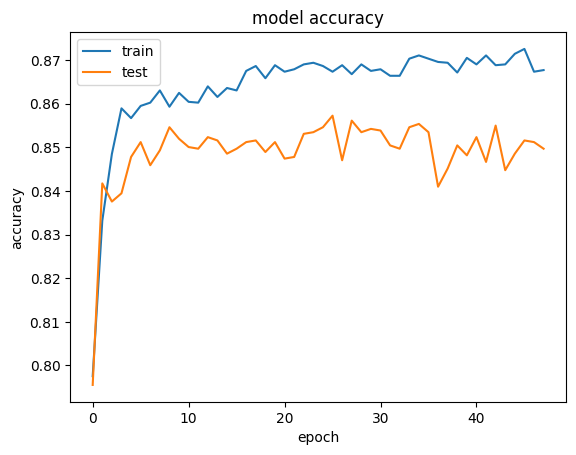

In [67]:
# plotting the trainnig test datas
plt.plot(modelCheck.history['accuracy'])
plt.plot(modelCheck.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

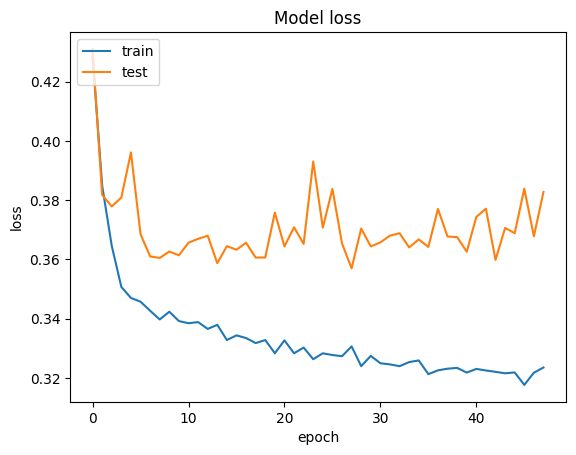

In [68]:
# to plot the loss
plt.plot(modelCheck.history['loss'])
plt.plot(modelCheck.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [69]:
# making the predictions

y_pre = classfier.predict(x_test)
y_pre = (y_pre > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [71]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pre)

In [72]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pre)

In [73]:
score

0.8595

In [76]:
classfier.get_weights()
# it gives the complete weights that been used in the neural network

[array([[-9.2596865e-01, -1.1002257e+00,  8.3626413e-01,  6.1465013e-01,
         -4.2802027e-01,  6.3061339e-01, -4.1874027e-01, -3.7600687e-01,
          3.3005840e-01, -4.1942662e-01, -7.3820907e-01],
        [-1.2935089e+00,  4.9112889e-01, -2.6099215e+00, -4.0320835e+00,
          2.5951896e+00, -1.2906947e+00, -1.3957079e-01,  2.4923370e+00,
          2.6111269e-01, -2.9052284e+00, -1.3179199e-01],
        [-8.2231694e-01,  7.9544747e-01,  6.9893700e-01, -9.6060824e-01,
         -8.7922728e-01,  8.9152478e-02,  3.0901584e-01,  1.0621130e+00,
          1.9637477e-03,  6.3371414e-01,  4.6328771e-01],
        [ 2.0566926e+00, -4.2938161e-01, -2.0243313e+00, -1.4636863e+00,
          5.6408423e-01, -2.0897179e+00, -3.1954570e+00, -1.1884947e+00,
         -2.1817172e-01, -9.0147704e-01,  9.0293229e-01],
        [ 1.0758277e+00, -1.7676954e+00, -2.6104978e-01, -7.8862041e-01,
          8.3585747e-02, -1.6496548e-01, -3.5760918e+00, -2.7843717e-01,
          3.0293214e+00,  7.0932858e-0